## Beam Dyanimcs

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import mint
from mint import plot_tools as pt
from mint import lattice_tools as lt

from mint.MuC import MuDecaySimulator

## RLA

In [3]:

RLA2_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

RLA2_numu.decay_muons()

[ 2157.68        2160.60501144  2163.53002288 ... 17587.56156373
 17590.48657517 17593.4115866 ]
Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x11d78a300>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x11d78f380>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])


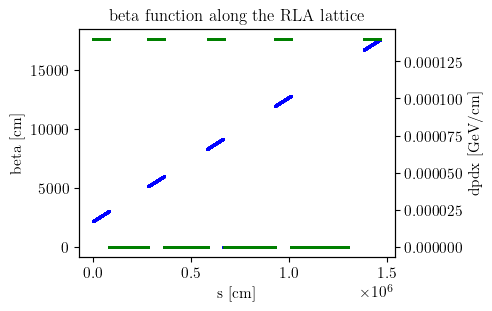

In [4]:
RLA2_lattice = lt.create_RLA_lattice(
            name = r"RLA2",
            short_name= "rla2",
            straight_length=829e2,
            n_elements=100_000,
            p0_injection=5.0,
            dp_dx_LA=11.6/829e2,
            beamdiv_z=1e-2,
            half=False,
            Nmu_per_bunch=2e12,
)

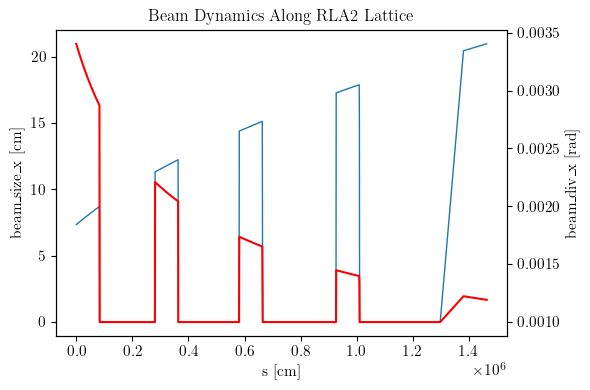

In [5]:
# u ranges from 0 → 1
u_vals = np.linspace(0, 1, 2000)

# Convert to actual s-position (in cm):
s_vals = u_vals * 1463126.8482550883   # or lattice.length

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(s_vals, RLA2_lattice.beamsize_x(u_vals), linewidth=1.0)

ax2 = ax.twinx()
ax2.plot(s_vals, RLA2_lattice.beamdiv_x(u_vals), color="red")

ax.set_xlabel("s [cm]")
ax.set_ylabel("beam_size_x [cm]")
ax2.set_ylabel("beam_div_x [rad]")
ax.set_title("Beam Dynamics Along RLA2 Lattice")
plt.tight_layout()
plt.show()

sample_size: 937478
pos x range: -32506.82354468825 19.326080775668068 32506.814554939265
pos y range: -83.2194580131205 -0.0030804471973056797 82.58947549200896
pos z range: -155010.70599565151 -5852.547734323572 143052.37384771914
s_in_turn min/max: 4.684001635343159 1463129.8137039554
u_parameter min/max: 3.2013565521848975e-06 0.9999996969375667
mutimes min/max: 1.5627657013306953e-10 4.880482554986099e-05
muon_lifetime min/max: 0.00010143936702587247 0.0013596081748755982


Text(0.5, 1.0, 'RLA 2')

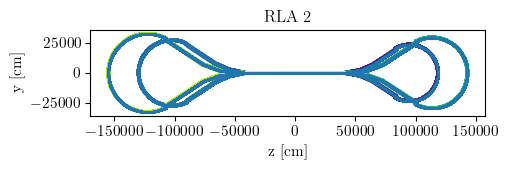

In [6]:
RLA2_numu.place_muons_on_lattice(lattice=RLA2_lattice, direction="clockwise")

max_index = len(RLA2_lattice.vertices[1])

fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(RLA2_lattice.vertices[0], RLA2_lattice.vertices[1], c=np.linspace(0, 1, max_index), marker='+', s=10)
ax.scatter(RLA2_numu.pos['z'], RLA2_numu.pos['x'], marker='.', s=0.25)

fig.gca().set_aspect('equal', adjustable='box')

ax.set_xlabel("z [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("RLA 2")

In [7]:
def plot_avgE_vs_time(MuC_acc_numu):
    # Bin mutimes and compute average neutrino energy in each bin
    bins = np.linspace(MuC_acc_numu.mutimes.min(), MuC_acc_numu.mutimes.max(), 50)
    digitized = np.digitize(MuC_acc_numu.mutimes, bins)
    avg_mu_E = [MuC_acc_numu.pmu['E'][digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))]
    avg_numu_E = [MuC_acc_numu.pnu['E'][digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))]
    
    fig, ax = pt.std_fig(figsize=(4,3))
    ax.step(1e6*bins[:-1], avg_mu_E, linestyle='-', color='grey', label=r'$\langle E_{\mu} \rangle$')
    ax.step(1e6*bins[:-1], avg_numu_E, linestyle='-', color='dodgerblue', label=r'$\langle E_{\nu_\mu} \rangle$')
    ax.set_xlabel('time ($\mu$s)')
    ax.set_ylabel(r'Average neutrino energy [GeV]')
    ax.legend(frameon=False, loc='upper left')
    return fig, ax

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='time ($\\mu$s)', ylabel='Average neutrino energy [GeV]'>)

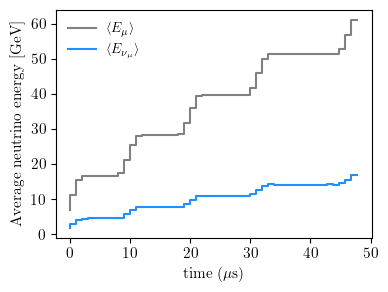

In [8]:
plot_avgE_vs_time(RLA2_numu)

In [9]:
def get_event_map_fixed_z(
        self,
        detect_loc,
        xrange=(-5000, 5000),
        yrange=(-77245, 1e3),
        nx=100,
        ny=100,
        det_radius=1e2,
    ):
        # print(np.max(self.mutimes))
        # print(np.sum(self.weights[:,0]))

        p_dir = self.pnu.to_3D().unit()

        event_map = np.zeros((nx, ny))
        X = None
        Y = None

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            events, x_arr, y_arr = np.histogram2d(
                x_hit[in_acceptance],
                y_hit[in_acceptance],
                bins=[nx, ny],
                range=[xrange, yrange],
                weights=self.weights[in_acceptance, 0] * P_int,
            )

            event_map += events  # accumulate directly, no concatenation

            event_map *= 5 * np.pi * 1e7  # 5 Hz injection rate * seconds in a year
            if X is None:
                X, Y = x_arr, y_arr

                
        total_events = np.sum(event_map)
        return X, Y, event_map, total_events

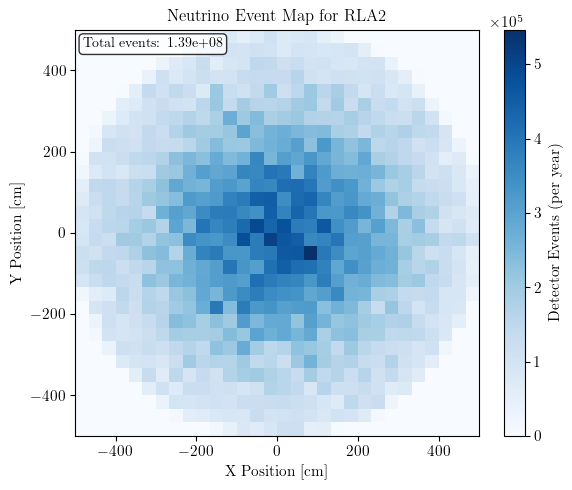

In [10]:
X, Y, event_map, tot_sum = get_event_map_fixed_z(
    RLA2_numu,
    detect_loc=[(1500e2, 0)],
    xrange=(-500,500),  
    yrange=(-500, 500),      
    nx=30,
    ny=30,
    det_radius=5e2              # 10m detector
)


import matplotlib.ticker as ticker

plt.figure(figsize=(6, 5))
c = plt.pcolormesh(X, Y, event_map.T, shading='auto', cmap='Blues', vmin=1e-10)
cb = plt.colorbar(c, label='Detector Events (per year)')

# Force scientific notation on the colorbar
cb.formatter = ticker.ScalarFormatter()
cb.formatter.set_powerlimits((-2, 2))   # scientific notation outside [-2, 2]
cb.update_ticks()

plt.text(
    0.02, 0.98,
    f"Total events: {tot_sum:.2e}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
)

plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title("Neutrino Event Map for RLA2")
plt.tight_layout()
plt.show()

## Racetrack RLA Design

In [11]:
racetrack_RLA_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

racetrack_RLA_numu.decay_muons()

In [12]:
racetrack_RLA_data=np.array([[-1.763e+4, -5.846e+3],
[-1.747e+4, -5.556e+3],
[-1.752e+4, -5.261e+3],
[-1.731e+4, -4.987e+3],
[-1.734e+4, -4.738e+3],
[-1.711e+4, -4.297e+3],
[-1.691e+4, -3.921e+3],
[-1.682e+4, -3.641e+3],
[-1.661e+4, -3.361e+3],
[-1.650e+4, -3.089e+3],
[-1.632e+4, -2.829e+3],
[-1.601e+4, -2.513e+3],
[-1.567e+4, -2.152e+3],
[-1.532e+4, -1.823e+3],
[-1.503e+4, -1.565e+3],
[-1.462e+4, -1.318e+3],
[-1.434e+4, -1.068e+3],
[-1.384e+4, -8.064e+2],
[-1.328e+4, -5.573e+2],
[-1.261e+4, -3.406e+2],
[-1.168e+4, -9.899e+1],
[-1.069e+4, -1.352e+1],
[-9.697e+3, -8.668e+0],
[-8.706e+3, -8.668e+0],
[-7.715e+3, -8.668e+0],
[-6.723e+3, -8.668e+0],
[-5.732e+3, -8.668e+0],
[-4.741e+3, -8.668e+0],
[-3.750e+3, -8.668e+0],
[-2.758e+3, -8.668e+0],
[-1.767e+3, -8.668e+0],
[-7.755e+2, -8.668e+0],
[2.158e+2, -8.668e+0],
[1.207e+3, -8.668e+0],
[2.198e+3, -8.668e+0],
[3.190e+3, -8.668e+0],
[4.181e+3, -8.668e+0],
[5.172e+3, -8.668e+0],
[6.164e+3, -8.668e+0],
[7.155e+3, -8.668e+0],
[8.146e+3, -8.668e+0],
[9.138e+3, -8.668e+0],
[1.013e+4, -8.668e+0],
[1.112e+4, -8.668e+0],
[1.211e+4, -8.668e+0],
[1.310e+4, -8.668e+0],
[1.409e+4, -8.668e+0],
[1.509e+4, -8.668e+0],
[1.608e+4, -8.668e+0],
[1.707e+4, -8.668e+0],
[1.806e+4, -8.668e+0],
[1.905e+4, -8.668e+0],
[2.004e+4, -8.668e+0],
[2.103e+4, -8.668e+0],
[2.202e+4, -8.668e+0],
[2.302e+4, -8.668e+0],
[2.401e+4, -8.668e+0],
[2.500e+4, -8.668e+0],
[2.599e+4, -8.668e+0],
[2.698e+4, -8.668e+0],
[2.797e+4, -8.668e+0],
[2.896e+4, -8.668e+0],
[2.996e+4, -8.668e+0],
[3.095e+4, -8.668e+0],
[3.194e+4, -8.668e+0],
[3.293e+4, -8.668e+0],
[3.392e+4, -8.668e+0],
[3.491e+4, -8.668e+0],
[3.590e+4, -8.668e+0],
[3.689e+4, -8.668e+0],
[3.789e+4, -8.668e+0],
[3.888e+4, -8.668e+0],
[3.987e+4, -8.668e+0],
[4.086e+4, -8.668e+0],
[4.185e+4, -8.668e+0],
[4.284e+4, -8.668e+0],
[4.383e+4, -8.668e+0],
[4.483e+4, -8.668e+0],
[4.582e+4, -8.668e+0],
[4.681e+4, -8.668e+0],
[4.780e+4, -8.668e+0],
[4.879e+4, -8.668e+0],
[4.978e+4, -8.668e+0],
[5.077e+4, -8.668e+0],
[5.176e+4, -8.668e+0],
[5.276e+4, -8.668e+0],
[5.375e+4, -8.668e+0],
[5.474e+4, -8.668e+0],
[5.573e+4, -8.668e+0],
[5.672e+4, -8.668e+0],
[5.771e+4, -8.668e+0],
[5.870e+4, -8.668e+0],
[5.970e+4, -8.668e+0],
[6.069e+4, -8.668e+0],
[6.168e+4, -8.668e+0],
[6.267e+4, -8.668e+0],
[6.366e+4, -8.668e+0],
[6.465e+4, -8.668e+0],
[6.564e+4, -1.255e+1],
[6.663e+4, -1.935e+1],
[6.763e+4, -1.935e+1],
[6.862e+4, -1.935e+1],
[6.961e+4, -1.935e+1],
[7.060e+4, -1.935e+1],
[7.159e+4, -1.935e+1],
[7.258e+4, -1.935e+1],
[7.357e+4, -1.935e+1],
[7.456e+4, -1.935e+1],
[7.556e+4, -1.935e+1],
[7.655e+4, -1.935e+1],
[7.754e+4, -1.935e+1],
[7.853e+4, -1.935e+1],
[7.952e+4, -1.935e+1],
[8.051e+4, -1.935e+1],
[8.150e+4, -1.935e+1],
[8.250e+4, -1.935e+1],
[8.349e+4, -1.935e+1],
[8.448e+4, -1.935e+1],
[8.547e+4, -1.935e+1],
[8.646e+4, -1.935e+1],
[8.745e+4, -1.935e+1],
[8.844e+4, -1.935e+1],
[8.943e+4, -1.935e+1],
[9.043e+4, -1.935e+1],
[9.142e+4, -1.935e+1],
[9.241e+4, -1.935e+1],
[9.340e+4, -1.935e+1],
[9.439e+4, -1.935e+1],
[9.538e+4, -1.935e+1],
[9.637e+4, -1.935e+1],
[9.737e+4, -1.935e+1],
[9.836e+4, -1.935e+1],
[9.935e+4, -1.935e+1],
[1.003e+5, -1.935e+1],
[1.013e+5, -1.935e+1],
[1.023e+5, -8.539e+1],
[1.033e+5, -2.748e+2],
[1.037e+5, -4.754e+2],
[1.043e+5, -6.834e+2],
[1.049e+5, -9.420e+2],
[1.053e+5, -1.206e+3],
[1.055e+5, -1.419e+3],
[1.059e+5, -1.681e+3],
[1.062e+5, -1.965e+3],
[1.065e+5, -2.241e+3],
[1.068e+5, -2.515e+3],
[1.070e+5, -2.834e+3],
[1.073e+5, -3.191e+3],
[1.075e+5, -3.513e+3],
[1.076e+5, -3.759e+3],
[1.077e+5, -4.008e+3],
[1.079e+5, -4.255e+3],
[1.080e+5, -4.530e+3],
[1.080e+5, -4.753e+3],
[1.082e+5, -5.004e+3],
[1.082e+5, -5.256e+3],
[1.084e+5, -5.539e+3],
[1.084e+5, -5.797e+3],
[1.083e+5, -6.040e+3],
[1.084e+5, -6.293e+3],
[1.085e+5, -6.571e+3],
[1.085e+5, -6.819e+3],
[1.085e+5, -7.054e+3],
[1.085e+5, -7.289e+3],
[1.085e+5, -7.524e+3],
[1.085e+5, -7.679e+3],
[1.084e+5, -7.950e+3],
[1.084e+5, -8.289e+3],
[1.084e+5, -8.494e+3],
[1.082e+5, -8.833e+3],
[1.082e+5, -9.104e+3],
[1.080e+5, -9.372e+3],
[1.079e+5, -9.728e+3],
[1.078e+5, -1.005e+4],
[1.076e+5, -1.035e+4],
[1.074e+5, -1.066e+4],
[1.072e+5, -1.094e+4],
[1.071e+5, -1.121e+4],
[1.068e+5, -1.155e+4],
[1.064e+5, -1.189e+4],
[1.062e+5, -1.218e+4],
[1.058e+5, -1.244e+4],
[1.055e+5, -1.270e+4],
[1.052e+5, -1.297e+4],
[1.047e+5, -1.321e+4],
[1.040e+5, -1.351e+4],
[1.033e+5, -1.377e+4],
[1.023e+5, -1.392e+4],
[1.013e+5, -1.399e+4],
[1.003e+5, -1.399e+4],
[9.935e+4, -1.399e+4],
[9.836e+4, -1.399e+4],
[9.737e+4, -1.399e+4],
[9.637e+4, -1.399e+4],
[9.538e+4, -1.399e+4],
[9.439e+4, -1.399e+4],
[9.340e+4, -1.399e+4],
[9.241e+4, -1.399e+4],
[9.142e+4, -1.399e+4],
[9.043e+4, -1.399e+4],
[8.943e+4, -1.399e+4],
[8.844e+4, -1.399e+4],
[8.745e+4, -1.399e+4],
[8.646e+4, -1.399e+4],
[8.547e+4, -1.399e+4],
[8.448e+4, -1.399e+4],
[8.349e+4, -1.399e+4],
[8.250e+4, -1.399e+4],
[8.150e+4, -1.399e+4],
[8.051e+4, -1.399e+4],
[7.952e+4, -1.399e+4],
[7.853e+4, -1.399e+4],
[7.754e+4, -1.399e+4],
[7.655e+4, -1.399e+4],
[7.556e+4, -1.399e+4],
[7.456e+4, -1.399e+4],
[7.357e+4, -1.399e+4],
[7.258e+4, -1.399e+4],
[7.159e+4, -1.399e+4],
[7.060e+4, -1.399e+4],
[6.961e+4, -1.399e+4],
[6.862e+4, -1.399e+4],
[6.763e+4, -1.399e+4],
[6.663e+4, -1.399e+4],
[6.564e+4, -1.399e+4],
[6.465e+4, -1.399e+4],
[6.366e+4, -1.399e+4],
[6.267e+4, -1.399e+4],
[6.168e+4, -1.399e+4],
[6.069e+4, -1.399e+4],
[5.970e+4, -1.399e+4],
[5.870e+4, -1.399e+4],
[5.771e+4, -1.399e+4],
[5.672e+4, -1.399e+4],
[5.573e+4, -1.399e+4],
[5.474e+4, -1.399e+4],
[5.375e+4, -1.399e+4],
[5.276e+4, -1.399e+4],
[5.176e+4, -1.399e+4],
[5.077e+4, -1.399e+4],
[4.978e+4, -1.399e+4],
[4.879e+4, -1.399e+4],
[4.780e+4, -1.399e+4],
[4.681e+4, -1.399e+4],
[4.582e+4, -1.399e+4],
[4.483e+4, -1.399e+4],
[4.383e+4, -1.399e+4],
[4.284e+4, -1.399e+4],
[4.185e+4, -1.399e+4],
[4.086e+4, -1.399e+4],
[3.987e+4, -1.399e+4],
[3.888e+4, -1.399e+4],
[3.789e+4, -1.399e+4],
[3.689e+4, -1.399e+4],
[3.590e+4, -1.399e+4],
[3.491e+4, -1.399e+4],
[3.392e+4, -1.399e+4],
[3.293e+4, -1.399e+4],
[3.194e+4, -1.399e+4],
[3.095e+4, -1.399e+4],
[2.996e+4, -1.399e+4],
[2.896e+4, -1.398e+4],
[2.797e+4, -1.398e+4],
[2.698e+4, -1.398e+4],
[2.599e+4, -1.398e+4],
[2.500e+4, -1.398e+4],
[2.401e+4, -1.398e+4],
[2.302e+4, -1.398e+4],
[2.202e+4, -1.398e+4],
[2.103e+4, -1.398e+4],
[2.004e+4, -1.398e+4],
[1.905e+4, -1.398e+4],
[1.806e+4, -1.398e+4],
[1.707e+4, -1.398e+4],
[1.608e+4, -1.398e+4],
[1.509e+4, -1.398e+4],
[1.409e+4, -1.398e+4],
[1.310e+4, -1.398e+4],
[1.211e+4, -1.398e+4],
[1.112e+4, -1.398e+4],
[1.013e+4, -1.398e+4],
[9.138e+3, -1.398e+4],
[8.146e+3, -1.398e+4],
[7.155e+3, -1.398e+4],
[6.164e+3, -1.398e+4],
[5.172e+3, -1.398e+4],
[4.181e+3, -1.398e+4],
[3.190e+3, -1.398e+4],
[2.198e+3, -1.398e+4],
[1.207e+3, -1.398e+4],
[2.158e+2, -1.398e+4],
[-7.755e+2, -1.398e+4],
[-1.767e+3, -1.398e+4],
[-2.758e+3, -1.398e+4],
[-3.750e+3, -1.398e+4],
[-4.741e+3, -1.398e+4],
[-5.732e+3, -1.398e+4],
[-6.723e+3, -1.398e+4],
[-7.715e+3, -1.398e+4],
[-8.706e+3, -1.398e+4],
[-9.697e+3, -1.398e+4],
[-1.069e+4, -1.398e+4],
[-1.168e+4, -1.390e+4],
[-1.266e+4, -1.373e+4],
[-1.334e+4, -1.347e+4],
[-1.393e+4, -1.322e+4],
[-1.432e+4, -1.301e+4],
[-1.468e+4, -1.273e+4],
[-1.518e+4, -1.239e+4],
[-1.558e+4, -1.206e+4],
[-1.584e+4, -1.176e+4],
[-1.614e+4, -1.146e+4],
[-1.631e+4, -1.116e+4],
[-1.660e+4, -1.084e+4],
[-1.677e+4, -1.056e+4],
[-1.693e+4, -1.024e+4],
[-1.703e+4, -9.929e+3],
[-1.723e+4, -9.588e+3],
[-1.736e+4, -9.218e+3],
[-1.754e+4, -8.864e+3],
[-1.754e+4, -8.641e+3],
[-1.758e+4, -8.368e+3],
[-1.771e+4, -8.072e+3],
[-1.767e+4, -7.826e+3],
[-1.767e+4, -7.591e+3],
[-1.767e+4, -7.356e+3],
[-1.767e+4, -7.121e+3],
[-1.767e+4, -6.886e+3],
[-1.767e+4, -6.651e+3],
[-1.767e+4, -6.416e+3],
[-1.767e+4, -6.181e+3]
])

In [12]:
xvals, yvals = racetrack_RLA_data[:,0], racetrack_RLA_data[:,1]
lattice_dic = lt.create_lattice_dict_from_vertices((xvals, yvals), n_elements=10_000)
lattice_dic.update(beam_p0=3.8,
            beamdiv=1e-3,
            beamdiv_z=0.1,
            beamsize=1,
            Nmu_per_bunch=1e6,)
racetrack_RLA = lt.Lattice(**lattice_dic)
racetrack_RLA.vertices = (xvals,yvals, np.full_like(xvals, 0))

NameError: name 'racetrack_RLA_data' is not defined

sample_size: 937345
pos x range: -13994.25413050294 -6999.370114807537 -3.7418129492775005
pos y range: -4.871717611389887 -0.00013193556448826428 4.850767424831017
pos z range: -17709.332954325553 45401.90577892491 108504.24770592486
s_in_turn min/max: 0.7015279751557035 268292.35237058013
u_parameter min/max: 2.614782247611913e-06 0.9999972987434034
mutimes min/max: 2.3411708983341036e-11 8.95562953023158e-06
muon_lifetime min/max: 4.05267678236753e-05 0.00011463812897051138


Text(0.5, 1.0, 'Muon decay positions in racetrack RLA')

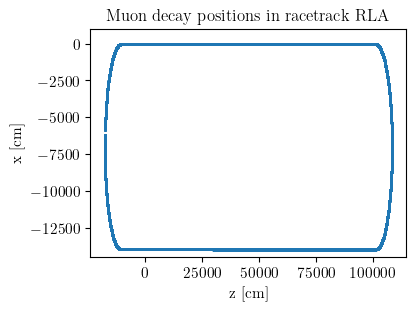

In [ ]:
racetrack_RLA_numu.place_muons_on_lattice(lattice=racetrack_RLA, direction="clockwise")

fig, ax = pt.std_fig(figsize=(4, 3))
#ax.scatter(racetrack_RLA.vertices[0], racetrack_RLA.vertices[1], c='black', marker='+', s=10)
ax.scatter(racetrack_RLA_numu.pos['z'], racetrack_RLA_numu.pos['x'], marker='.', s=0.5)
#fig.gca().set_aspect('equal', adjustable='box')
ax.set_ylim(-145e2,10e2)
ax.set_xlabel("z [cm]")
ax.set_ylabel("x [cm]")
ax.set_title("Muon decay positions in racetrack RLA")

At a given detecct loc, # of nu events per time
(1 with beam dynamics) *expect to be gaussian
(1 w/o bd) * muon decay

In [15]:
def get_event_counts_vs_time(
        self,
        detect_loc,
        nbins=200,
        t_bins=None,
        det_radius=1e2,
    ):
        """Return event counts binned in muon decay time for the given detector locations.

        Args:
            detect_loc: list of (z_det, y_offset) detector tuples (same as get_event_map_fixed_z)
            nbins: number of time bins to use if t_bins is None
            t_bins: optional array of bin edges in seconds
            det_radius: detector acceptance radius (cm)

        Returns:
            (t_centers, counts) where t_centers are bin centres in seconds and counts are
            the predicted number of neutrino interaction events (weights * P_int) in each bin.
        """
        p_dir = self.pnu.to_3D().unit()

        # contributions per simulated decay
        contributions = np.zeros(self.sample_size)

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            contributions[in_acceptance] += self.weights[in_acceptance, 0] * P_int

        times = np.asarray(self.mutimes)
        if t_bins is None:
            tmin, tmax = times.min(), times.max()
            t_bins = np.linspace(tmin, tmax, nbins + 1)

        counts, edges = np.histogram(times, bins=t_bins, weights=contributions)
        centers = 0.5 * (edges[:-1] + edges[1:])
        return centers, counts

def plot_event_counts_vs_time(
        self,
        detect_loc,
        nbins=200,
        t_bins=None,
        det_radius=1e2,
        figsize=(6, 3),
        xlabel=None,
        ylabel=None,
    ):
        """Plot predicted neutrino interaction counts vs muon decay time.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt

        centers, counts = get_event_counts_vs_time(
            self=self, detect_loc=detect_loc, nbins=nbins, t_bins=t_bins, det_radius=det_radius
        )

        fig, ax = plt.subplots(figsize=figsize)
        ax.step(1e9 * centers, counts, where="mid", color="C0")
        ax.set_xlabel(xlabel or "muon time (ns)")
        ax.set_ylabel(ylabel or "Predicted neutrino events")
        ax.grid(True)
        return fig, ax

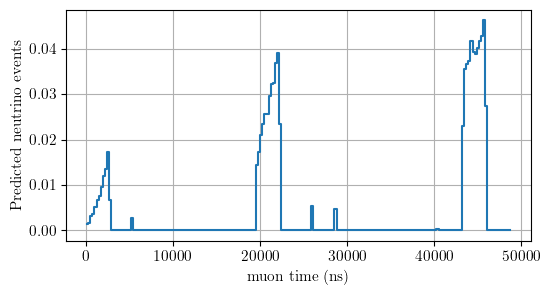

In [16]:
fig, ax = plot_event_counts_vs_time(
    RLA2_numu,
    detect_loc=[(1500e2, 0)],
    det_radius=5e2
)

Version with no Beam dynamics

In [17]:
RLA2_numu_noBD = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

RLA2_numu_noBD.decay_muons()

Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x1369aed00>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x1369b5760>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])


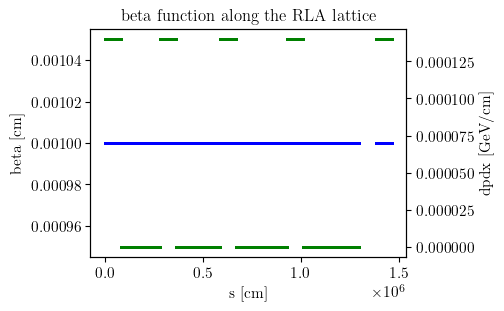

In [18]:
RLA2_noBD_lattice = lt.create_RLA_lattice(
            beam_dyn=False,
            name = r"RLA2",
            short_name= "rla2",
            straight_length=829e2,
            n_elements=100_000,
            p0_injection=5.0,
            dp_dx_LA=11.6/829e2,
            beamdiv=1e-10,
            beamdiv_z=1e-2,
            beamsize=1e-2,
            half=False,
            Nmu_per_bunch=2e12,
)

sample_size: 937528
pos x range: -32506.837485873217 -21.358180918958467 32506.819674142724
pos y range: -0.044131999316504834 -1.5135217497791358e-05 0.04462892726099808
pos z range: -155010.72948452315 -5837.035650521471 143052.38953945338
s_in_turn min/max: 0.46813412547391786 1463129.9381541805
u_parameter min/max: 3.199538272102842e-07 0.9999997819950827
mutimes min/max: 1.5618704701388308e-11 4.8804831548545274e-05
muon_lifetime min/max: 0.00010131675125178367 0.0013538004213577406


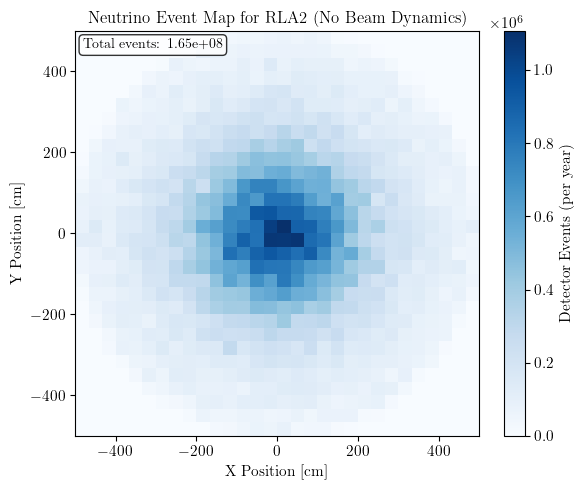

In [19]:
RLA2_numu_noBD.place_muons_on_lattice(lattice=RLA2_noBD_lattice, direction="clockwise")

X, Y, event_map_noBD, tot_sum_noBD = get_event_map_fixed_z(
    RLA2_numu_noBD,
    detect_loc=[(1500e2, 0)],
    xrange=(-500,500),  
    yrange=(-500, 500),      
    nx=30,
    ny=30,
    det_radius=5e2              # 10m detector
)


import matplotlib.ticker as ticker

plt.figure(figsize=(6, 5))
c = plt.pcolormesh(X, Y, event_map_noBD.T, shading='auto', cmap='Blues', vmin=1e-10)
cb = plt.colorbar(c, label='Detector Events (per year)')

# Force scientific notation on the colorbar
cb.formatter = ticker.ScalarFormatter()
cb.formatter.set_powerlimits((-2, 2))   # scientific notation outside [-2, 2]
cb.update_ticks()

plt.text(
    0.02, 0.98,
    f"Total events: {tot_sum_noBD:.2e}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
)

plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title("Neutrino Event Map for RLA2 (No Beam Dynamics)")
plt.tight_layout()
plt.show()

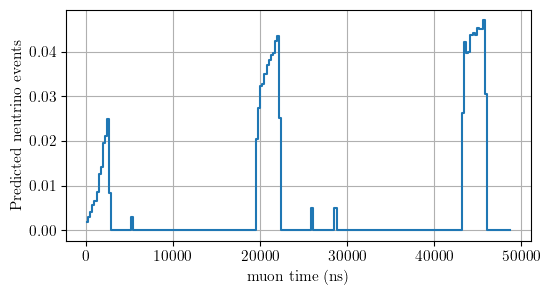

In [20]:
fig, ax = plot_event_counts_vs_time(
    RLA2_numu_noBD,
    detect_loc=[(1500e2, 0)],
    det_radius=5e2
)

## Collider

In [13]:
import pickle
with open('beam-optics/ring_v06_smoothed.pkl', 'rb') as f:
    lattice_10TeV_dict = pickle.load(f)

lattice_10TeV = lt.Lattice(**lattice_10TeV_dict)

collider_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

collider_numu.decay_muons()

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x14cf7fa20>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x14cf7fc00>
Warning! The following keys were not recognized and will be ignored: dict_keys(['dispersion_Dx', 'dispersion_Dpx'])


In [14]:
collider_numu.place_muons_on_lattice(lattice_10TeV)

sample_size: 937447
pos x range: -258706.8508286464 -129426.4929097358 0.0
pos y range: -7.073675472289111 -9.294587918063542e-05 5.670550231746821
pos z range: -142897.01768131598 52.645608180069125 142897.0176811516
s_in_turn min/max: 1.6259288105340877 866851.3364666802
u_parameter min/max: 2.149499204477669e-06 0.9999989366608061
mutimes min/max: 5.423514726635034e-11 2.8915048178437677e-05
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492


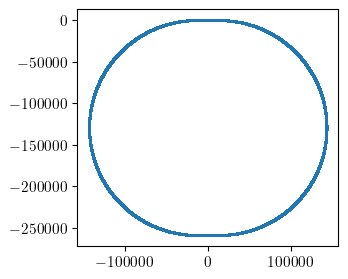

In [23]:
plt.scatter(collider_numu.pos['z'], collider_numu.pos['x'], marker='.', s=0.5)
plt.gca().set_aspect('equal', adjustable='box')

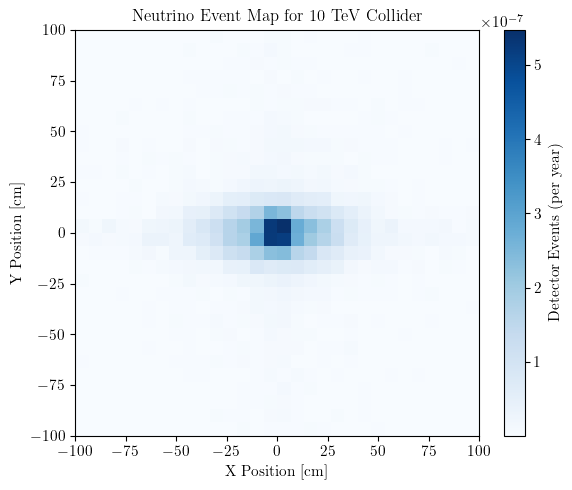

In [24]:
X, Y, event_map, _ = get_event_map_fixed_z(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    xrange=(-1e2,1e2),  
    yrange=(-1e2, 1e2),      
    nx=30,
    ny=30,
    det_radius=5e2               # 5m detector
)

import matplotlib.ticker as ticker

plt.figure(figsize=(6, 5))
c = plt.pcolormesh(X, Y, event_map, shading='auto', cmap='Blues', vmin=1e-10)
cb = plt.colorbar(c, label='Detector Events (per year)')

# Force scientific notation on the colorbar
cb.formatter = ticker.ScalarFormatter()
cb.formatter.set_powerlimits((-2, 2))   # scientific notation outside [-2, 2]
cb.update_ticks()

plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title("Neutrino Event Map for 10 TeV Collider")
plt.tight_layout()
plt.show()

In [75]:
def get_dNdr_vs_r(
        self,
        detect_loc,
        nbins=200,
        r_bins=None,
        det_radius=1e2,
        #collider=False,
    ):
        
        p_dir = self.pnu.to_3D().unit()

        # contributions per simulated decay
        contributions = np.zeros(self.sample_size)

        rvals = np.zeros(self.sample_size)

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r = np.sqrt(x_hit**2 + (y_hit + y_offset)**2)
            in_acceptance = (t_vals > 0) & (r < det_radius)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            contributions[in_acceptance] += self.weights[in_acceptance, 0] * P_int

            rvals[in_acceptance] = r[in_acceptance]


        if r_bins is None:
            r_bins = np.linspace(0, det_radius, nbins + 1)

        counts, edges = np.histogram(rvals, bins=r_bins, weights=contributions)

        dr = np.diff(edges)
        r_centers = 0.5 * (edges[:-1] + edges[1:])

        dNdr = counts #/ dr   # IMPORTANT STEP

        dNdr *= 5 * np.pi * 1E7  # 5 Hz injection rate * seconds in a year

        # if collider:
        #     dNdr *= 2e12 #take into account 2e12 Nmu per bunch if we create via lattice file

        return r_centers, dNdr

def plot_dNdr_vs_r(
        self,
        detect_loc,
        nbins=200,
        r_bins=None,
        det_radius=1e2,
        figsize=(6, 3),
        xlabel=None,
        ylabel=None,
    ):
        """Plot predicted neutrino interaction counts vs muon decay time.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt

        centers, dNdr = get_dNdr_vs_r(
            self=self, detect_loc=detect_loc, nbins=nbins, r_bins=r_bins, det_radius=det_radius,
        )

        fig, ax = plt.subplots(figsize=figsize)
        ax.step(centers, dNdr, where="mid", color="C0")
        ax.set_xlabel(xlabel or "radius (cm)")
        ax.set_ylabel(ylabel or r"$dN/dr$  [events / cm / year]")
        ax.grid(True)
        return fig, ax

(<Figure size 600x300 with 1 Axes>,
 <Axes: xlabel='radius (cm)', ylabel='$dN/dr$  [events / cm / year]'>)

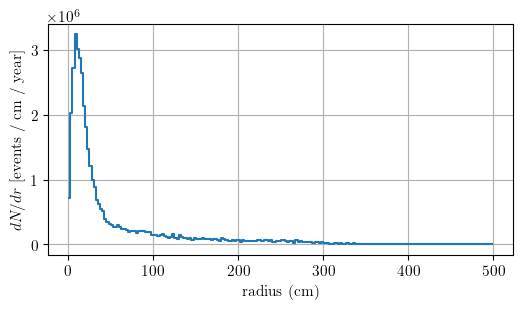

In [76]:
plot_dNdr_vs_r(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    det_radius=5e2,
)

In [49]:
def get_dNdcos_vs_cos(
        self,
        detect_loc,
        nbins=200,
        cos_bins=None,
        det_radius=1e2,
    ):
        
        p_dir = self.pnu.to_3D().unit()

        # contributions per simulated decay
        contributions = np.zeros(self.sample_size)

        cos = np.zeros(self.sample_size)

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r = np.sqrt(x_hit**2 + (y_hit + y_offset)**2)
            in_acceptance = (t_vals > 0) & (r < det_radius)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            contributions[in_acceptance] += self.weights[in_acceptance, 0] * P_int

            cos[in_acceptance] = p_dir["z"][in_acceptance]


        if cos_bins is None:
            cos_bins = np.linspace(1-1e-6, 1.0, nbins + 1)

        counts, edges = np.histogram(cos, bins=cos_bins, weights=contributions)

        dcos = np.diff(edges)
        cos_centers = 0.5 * (edges[:-1] + edges[1:])

        dNdcos = counts / dcos   # IMPORTANT STEP

        dNdcos *= 5 * np.pi * 1e7  # 5 Hz injection rate * seconds in a year

        return cos_centers, dNdcos

def plot_dNdcos_vs_cos(
        self,
        detect_loc,
        nbins=200,
        cos_bins=None,
        det_radius=1e2,
        figsize=(6, 3),
        xlabel=None,
        ylabel=None,
    ):
        """Plot predicted neutrino interaction counts vs muon decay time.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt

        centers, dNdcos = get_dNdcos_vs_cos(
            self=self, detect_loc=detect_loc, nbins=nbins, cos_bins=cos_bins, det_radius=det_radius
        )

        fig, ax = plt.subplots(figsize=figsize)
        ax.step(centers, dNdcos, where="mid", color="C0")
        ax.set_xlabel(xlabel or r"$\cos(\theta)$ ")
        ax.set_ylabel(ylabel or r"$dN/d\cos(\theta)$  [events / year]")
        ax.grid(True)
        return fig, ax

(<Figure size 600x300 with 1 Axes>,
 <Axes: xlabel='$\\cos(\\theta)$ ', ylabel='$dN/d\\cos(\\theta)$  [events / year]'>)

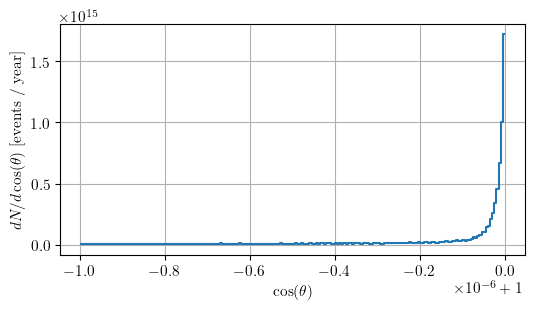

In [50]:
plot_dNdcos_vs_cos(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    det_radius=5e2
)

In [51]:
def get_event_counts_vs_energy(
        self,
        detect_loc,
        nbins=50,
        e_bins=None,
        log_e=True,
        det_radius=1e2,
    ):
        """Return event counts binned in neutrino energy for the given detector locations.

        Args:
            detect_loc: list of (z_det, y_offset) detector tuples (same as get_event_map_fixed_z)
            nbins: number of energy bins to use if e_bins is None
            e_bins: optional array of bin edges in GeV
            det_radius: detector acceptance radius (cm)

        Returns:
            (e_centers, counts) where e_centers are bin centres in GeV and counts are
            the predicted number of neutrino interaction events (weights * P_int) in each bin.
        """
        p_dir = self.pnu.to_3D().unit()

        # Store neutrino energies and interaction contributions for events in acceptance
        nu_energies = []
        weights_with_interaction = []

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            no_probability = np.sum(self.weights[in_acceptance, 0])

            weights_int = self.weights[in_acceptance, 0] * P_int

            print(weights_int)
            nu_energies.extend(self.pnu["E"][in_acceptance])
            weights_with_interaction.extend(weights_int)

        if len(nu_energies) == 0:
            # No events in acceptance, return empty bins
            if e_bins is None:
                if log_e:
                    e_bins = np.logspace(
                        -2, 2, nbins + 1
                    )  # Default energy range 0.01-10 GeV
                else:
                    e_bins = np.linspace(
                        0, 5, nbins + 1
                    )  # Default energy range 0-5 GeV
            counts = np.zeros(len(e_bins) - 1)
            centers = 0.5 * (e_bins[:-1] + e_bins[1:])
            return centers, counts

        nu_energies = np.asarray(nu_energies)
        weights_with_interaction = np.asarray(weights_with_interaction)

        if e_bins is None:
            emin, emax = nu_energies.min(), nu_energies.max()
            
            if log_e:
                    e_bins = np.logspace(np.log10(emin), np.log10(emax), nbins + 1)
            else:
                    e_bins = np.linspace(emin, emax, nbins + 1)
            

        counts, edges = np.histogram(
            nu_energies, bins=e_bins, weights=weights_with_interaction
        )
        centers = 0.5 * (edges[:-1] + edges[1:])

        counts *= 5 * np.pi * 1e7  # 5 Hz injection rate * seconds in a year

        sum = np.sum(counts)

        dE = np.diff(edges)

        counts /= dE

        return centers, counts, sum, no_probability

def get_event_counts_vs_energy_srange(
        self,
        s_range,
        nbins=50,
        e_bins=None,
        log_e=True,
    ):
        """
        Compute dN/dE from neutrinos whose muons decayed in a given s_muon region.

        Args:
            s_range: (s_min, s_max) defining accepted muon decay positions along lattice [cm]
            nbins:   number of energy bins if e_bins is None
            e_bins:  optional bin edges [GeV]
            log_e:   whether to use log-spaced bins

        Returns:
            (E_centers, dN/dE)
        """

        s_min, s_max = s_range

        # ---- Acceptance mask determined ONLY by muon decay position ----
        in_acceptance = (self.s_muon >= s_min) & (self.s_muon < s_max)

        if not np.any(in_acceptance):
            # No events → return empty spectrum
            if e_bins is None:
                if log_e:
                    e_bins = np.logspace(-2, 2, nbins + 1)
                else:
                    e_bins = np.linspace(0, 5, nbins + 1)

            centers = 0.5 * (e_bins[:-1] + e_bins[1:])
            counts = np.zeros_like(centers)
            return centers, counts

        # ---- Extract energies and interaction probabilities ----
        nu_E = self.pnu["E"][in_acceptance]  # neutrino energy
        sigma = nu_E * 1e-38  # cm²
        n_target = 1 / 1.67262192e-24  # nucleons/cm³
        P_int = n_target * sigma * 10e2  # linearized

        decay_w = self.weights[in_acceptance, 0]  # decay weights
        weights_int = decay_w * P_int  # weighted contribution

        # ---- Convert to numpy ----
        nu_E = np.asarray(nu_E)
        weights_int = np.asarray(weights_int)

        # ---- Energy binning ----
        if e_bins is None:
            emin, emax = nu_E.min(), nu_E.max()
            if log_e:
                e_bins = np.logspace(np.log10(emin), np.log10(emax), nbins + 1)
            else:
                e_bins = np.linspace(emin, emax, nbins + 1)

        counts, edges = np.histogram(nu_E, bins=e_bins, weights=weights_int)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # ---- Convert to per-year ----
        counts *= 5 * np.pi * 1e7

        # ---- Convert to dN/dE ----
        dE = np.diff(edges)
        counts /= dE

        return centers, counts

def plot_event_counts_vs_energy(
        self,
        detect_loc=None,
        detect=True,
        nbins=50,
        e_bins=None,
        log_e=True,
        det_radius=1e2,
        figsize=(6, 4),
        fig_and_ax=None,
        xlabel=None,
        ylabel=None,
        color="blue",
        label=None,
        s_range=None,
    ):
        """Plot predicted neutrino interaction counts vs neutrino energy.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt
        from scipy.interpolate import UnivariateSpline as uspline

        if detect:
            centers, counts, sum, no_probability = get_event_counts_vs_energy(
                self=self,
                detect_loc=detect_loc,
                nbins=nbins,
                e_bins=e_bins,
                log_e=log_e,
                det_radius=det_radius,
            )
        else:
            centers, counts= get_event_counts_vs_energy_srange(
                self=self, s_range=s_range, nbins=nbins, e_bins=e_bins, log_e=log_e
            )

        if fig_and_ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig, ax = fig_and_ax

        # Ensure arrays
        centers = np.asarray(centers)
        counts = np.asarray(counts)

        # Filter out non-positive values since log scale cannot display them
        mask = (centers > 0) & (counts > 0)
        if np.any(mask):
            # plot only positive bins on log-log axes
            (line,) = ax.step(centers[mask], counts[mask], where="mid")
            if log_e:
                ax.set_xscale("log")
                ax.set_yscale("log")
        else:
            # fallback to linear plot if no positive bins
            (line,) = ax.step(centers, counts, where="mid")
            import warnings

            warnings.warn(
                "No positive (center,count) pairs found for log-log plot; using linear scales instead."
            )

        line.set_color(color)
        if label:
            line.set_label(label)

        ax.set_xlabel(xlabel or "Neutrino Energy (GeV)")
        ax.set_ylabel(ylabel or "E dN/dE (per year)")
        ax.grid(True, which="both", ls="--", alpha=0.5)

        return fig, ax, label, sum, no_probability

[2.08960297e-11 6.88490537e-11 9.33364696e-11 ... 5.65442255e-06
 5.66367062e-06 7.60264380e-06]


(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Neutrino Energy (GeV)', ylabel='E dN/dE (per year)'>,
 None,
 np.float64(39931692.08292301),
 np.float64(24338061.904272255))

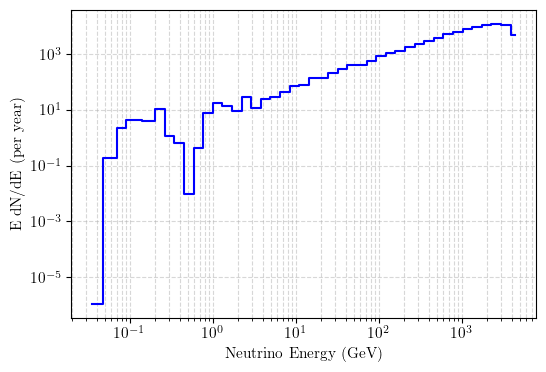

In [52]:
plot_event_counts_vs_energy(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    det_radius=5e2
)

In [53]:
def get_dNdx_vs_x(
        self,
        detect_loc,
        nbins=200,
        e_bins=None,
        det_radius=1e2,
    ):
        
        p_dir = self.pnu.to_3D().unit()

        # contributions per simulated decay
        contributions = np.zeros(self.sample_size)

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r = np.sqrt(x_hit**2 + (y_hit + y_offset)**2)
            in_acceptance = (t_vals > 0) & (r < det_radius)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            contributions[in_acceptance] += self.weights[in_acceptance, 0] * P_int


        if e_bins is None:
            e_bins = np.linspace(0, 5000, nbins + 1)

        counts, edges = np.histogram(self.pnu["E"], bins=e_bins, weights=contributions)

        dE = np.diff(edges)
        E_centers = 0.5 * (edges[:-1] + edges[1:])

        dNdE = counts / dE   # IMPORTANT STEP

        dNdE *= 5 * np.pi * 1e7  # 5 Hz injection rate * seconds in a year

        return E_centers, dNdE

def plot_dNdx_vs_x(
        self,
        detect_loc,
        nbins=200,
        e_bins=None,
        det_radius=1e2,
        figsize=(6, 3),
        xlabel=None,
        ylabel=None,
    ):
        """Plot predicted neutrino interaction counts vs muon decay time.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt

        centers, dNdcos = get_dNdx_vs_x(
            self=self, detect_loc=detect_loc, nbins=nbins, e_bins=e_bins, det_radius=det_radius
        )

        fig, ax = plt.subplots(figsize=figsize)
        ax.step(centers, dNdcos, where="mid", color="C0")
        ax.set_xlabel(xlabel or r"$x=2E_{\nu}/m_{\mu}$ ")
        ax.set_ylabel(ylabel or r"$dN/dx$  [events / year]")
        ax.grid(True)
        return fig, ax

(<Figure size 600x300 with 1 Axes>,
 <Axes: xlabel='$x=2E_{\\nu}/m_{\\mu}$ ', ylabel='$dN/dx$  [events / year]'>)

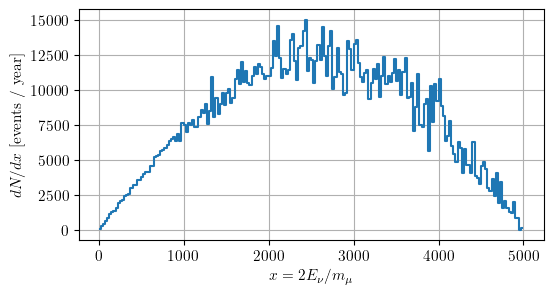

In [54]:
plot_dNdx_vs_x(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    det_radius=5e2
)

## Collider (without Beam Dynamics)

In [91]:
import pickle
with open('beam-optics/ring_v06_smoothed.pkl', 'rb') as f:
    lattice_10TeV_dict = pickle.load(f)

lattice_10TeV = lt.Lattice(**lattice_10TeV_dict)

collider_numu_noBD = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    beam_dynamics=False,
    cycles=1e3,
    )

collider_numu_noBD.decay_muons()

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x14f730ff0>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x14f731220>
Warning! The following keys were not recognized and will be ignored: dict_keys(['dispersion_Dx', 'dispersion_Dpx'])


In [92]:
collider_numu_noBD.place_muons_on_lattice(lattice_10TeV)

sample_size: 937507
pos x range: -258706.60523632573 -129349.96223789146 0.0
pos y range: 0.0 0.0 0.0
pos z range: -142897.01767846895 -162.08383449096192 142897.01767844905
s_in_turn min/max: 3.434434043127112 866851.8433893356
u_parameter min/max: 4.540366832609232e-06 0.9999996068192026
mutimes min/max: 3.355311635389695e-08 0.028915057993849698
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492


In [93]:
collider_numu_noBD.weights.sum()

np.float64(0.24278910090302278)

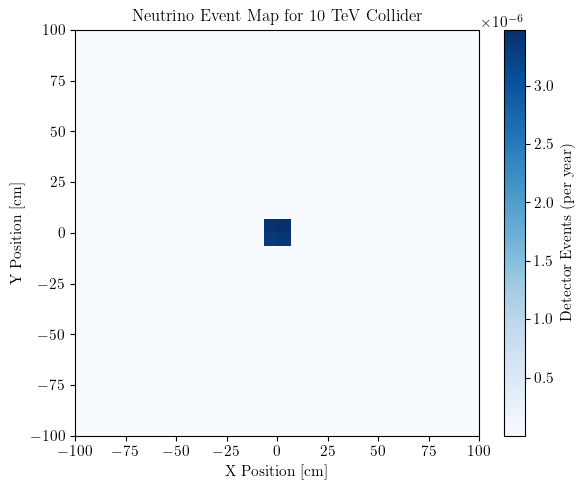

In [58]:
X, Y, event_map, _ = get_event_map_fixed_z(
    collider_numu_noBD,
    detect_loc=[(1000e2, 0)],
    xrange=(-1e2,1e2),  
    yrange=(-1e2, 1e2),      
    nx=30,
    ny=30,
    det_radius=5e2               # 5m detector
)

import matplotlib.ticker as ticker

plt.figure(figsize=(6, 5))
c = plt.pcolormesh(X, Y, event_map, shading='auto', cmap='Blues', vmin=1e-10)
cb = plt.colorbar(c, label='Detector Events (per year)')

# Force scientific notation on the colorbar
cb.formatter = ticker.ScalarFormatter()
cb.formatter.set_powerlimits((-2, 2))   # scientific notation outside [-2, 2]
cb.update_ticks()

plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title("Neutrino Event Map for 10 TeV Collider")
plt.tight_layout()
plt.show()

(<Figure size 600x300 with 1 Axes>,
 <Axes: xlabel='radius (cm)', ylabel='$dN/dr$  [events / cm / year]'>)

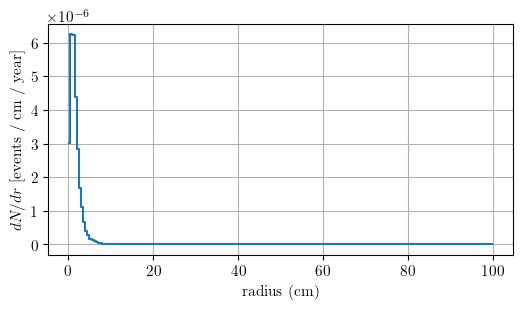

In [59]:
plot_dNdr_vs_r(
    collider_numu_noBD,
    detect_loc=[(1000e2, 0)],
    det_radius=1e2
)

(<Figure size 600x300 with 1 Axes>,
 <Axes: xlabel='$\\cos(\\theta)$ ', ylabel='$dN/d\\cos(\\theta)$  [events / year]'>)

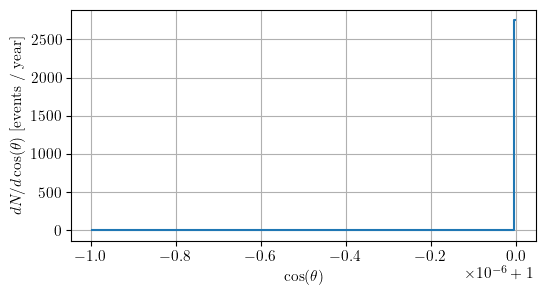

In [60]:
plot_dNdcos_vs_cos(
    collider_numu_noBD,
    detect_loc=[(1000e2, 0)],
    det_radius=1e2
)

[1.13030715e-24 3.90866950e-23 5.53342065e-23 ... 5.55093554e-18
 1.25017986e-18 4.81674788e-18]


(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Neutrino Energy (GeV)', ylabel='E dN/dE (per year)'>,
 None,
 np.float64(1.4703470274160105e-05),
 np.float64(8.932034569156828e-06))

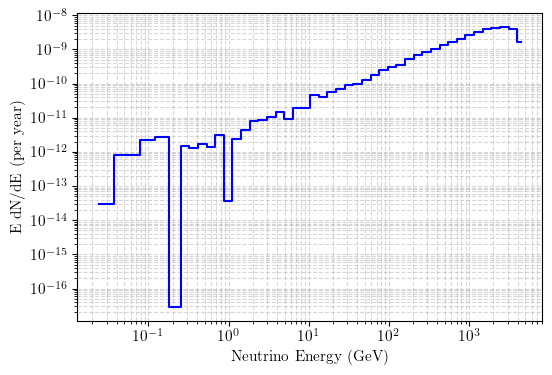

In [61]:
plot_event_counts_vs_energy(
    collider_numu_noBD,
    detect_loc=[(1000e2, 0)],
    det_radius=5e2
)

## Interaction Region for Collider

In [62]:
emittance_RMS = 0.5e-9 # meters

twiss_file_path_IR_v09_hybrid = 'beam-optics/twiss_ir1ccma_hybrid_v06.outx'
df_IR_v09_hybrid = lt.get_lattice_dataframe_from_tfs(twiss_file_path_IR_v09_hybrid)
lattice_dict_IR_v09_hybrid = lt.create_smoothed_lattice(df_IR_v09_hybrid, n_elements=50_000, midpoint=True, rotated=True, if_sublattice=True, emittance_RMS=emittance_RMS, Nmu_per_bunch=2e12,)


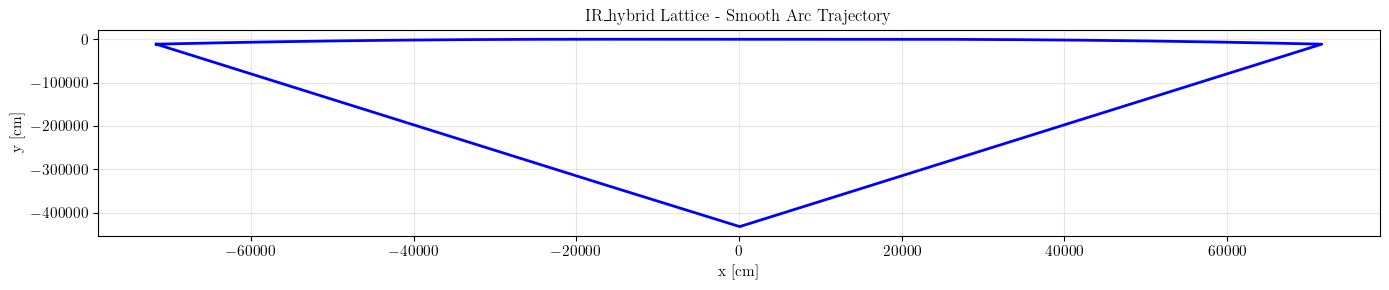

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(14, 3))
u_full = np.linspace(0, 1, 2000)
ax.plot(lattice_dict_IR_v09_hybrid['x'](u_full), lattice_dict_IR_v09_hybrid['y'](u_full), 'b-', linewidth=2)
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_title('IR_hybrid Lattice - Smooth Arc Trajectory')
ax.grid(True, alpha=0.3)
#ax.set_ylim(-10, 10)
#ax.set_xlim(-2e4, 2e4)
plt.tight_layout()

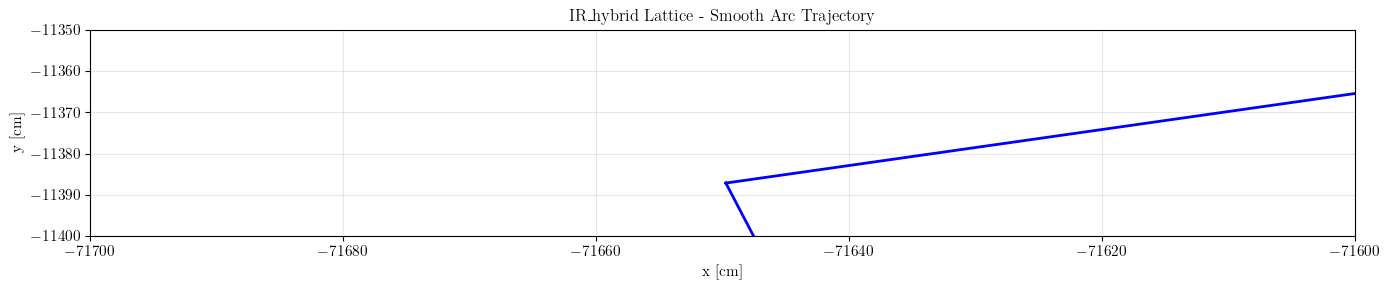

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(14, 3))
u_full = np.linspace(0, 1, 2000)
ax.plot(lattice_dict_IR_v09_hybrid['x'](u_full), lattice_dict_IR_v09_hybrid['y'](u_full), 'b-', linewidth=2)
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
ax.set_title('IR_hybrid Lattice - Smooth Arc Trajectory')
ax.grid(True, alpha=0.3)
ax.set_ylim(-11400, -11350)
ax.set_xlim(-71700, -71600)
plt.tight_layout()

In [67]:
print(lattice_dict_IR_v09_hybrid['x'](0))
print(lattice_dict_IR_v09_hybrid['y'](0))
print(lattice_dict_IR_v09_hybrid['x'](1))
print(lattice_dict_IR_v09_hybrid['y'](1))
print(lattice_dict_IR_v09_hybrid['s'](1))

-71649.75158410934
-11387.162306856248
-71649.75158410934
-11387.162306856248
1000029.8107476658


In [68]:
collider_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    remove_ring_fraction=[0,1-(146490.7102/lattice_dict_IR_v09_hybrid['s'](1))]
    )

collider_numu.decay_muons()
collider_numu.place_muons_on_lattice(lattice_dict_IR_v09_hybrid)

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x14ddee710>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x14db1ff70>
Warning! The following keys were not recognized and will be ignored: dict_keys(['dispersion_Dx', 'dispersion_Dpx'])
sample_size: 937519
pos x range: nan nan nan
pos y range: nan nan nan
pos z range: nan nan nan
s_in_turn min/max: 1.6624658989046506 1000029.338557086
u_parameter min/max: nan nan
mutimes min/max: 5.545389334897263e-11 5.003608462853326e-05
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492


In [70]:
# collider_numu.weights.sum()/1e8
collider_numu.lattice

In [71]:
collider_numu_noBD = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    beam_dynamics=False,
    remove_ring_fraction=[0,1-(146490.7102/lattice_dict_IR_v09_hybrid['s'](1))]
    )

collider_numu_noBD.decay_muons()
collider_numu_noBD.place_muons_on_lattice(lattice_dict_IR_v09_hybrid)

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x14ddee710>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x14db1ff70>
Warning! The following keys were not recognized and will be ignored: dict_keys(['dispersion_Dx', 'dispersion_Dpx'])
sample_size: 937545
pos x range: nan nan nan
pos y range: 0.0 0.0 0.0
pos z range: nan nan nan
s_in_turn min/max: 0.18112946352409962 1000028.6115421387
u_parameter min/max: nan nan
mutimes min/max: 6.04182856276328e-12 5.003606754090385e-05
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492


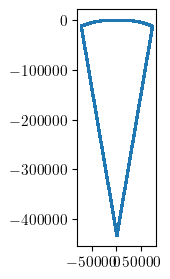

In [72]:
plt.scatter(collider_numu.pos['z'], collider_numu.pos['x'], marker='.', s=0.5)
plt.gca().set_aspect('equal', adjustable='box')

## Compare BD and No BD

In [90]:
collider_numu.mutimes.max()

np.float64(5.003608462853326e-05)

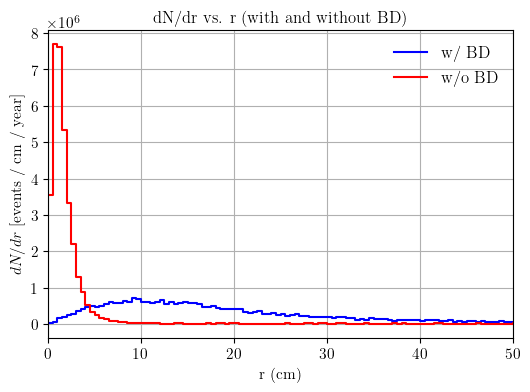

In [86]:
# Get the data for both distributions
r_centers, dNdr = get_dNdr_vs_r(
    collider_numu,
    detect_loc=[(1e5, 0)],
    det_radius=1e2
)

r_centers_noBD, dNdr_noBD = get_dNdr_vs_r(
    collider_numu_noBD,
    detect_loc=[(1e5, 0)],
    det_radius=1e2
)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# Plot both distributions on the same axis
ax.step(r_centers, dNdr, where="mid", color="blue", label="w/ BD")
ax.step(r_centers_noBD, dNdr_noBD, where="mid", color="red", label="w/o BD")
ax.set_xlabel("r (cm)")
ax.set_xlim(0,50)
ax.set_ylabel(r"$dN/dr$ [events / cm / year]")
ax.grid(True)
ax.legend(fontsize=12)
ax.set_title("dN/dr vs. r (with and without BD)")

# fig.tight_layout()
plt.show()

In [42]:
# Get the data for both distributions
cos_centers, dNdcos = get_dNdcos_vs_cos(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    det_radius=1e2
)

cos_centers_noBD, dNdcos_noBD = get_dNdcos_vs_cos(
    collider_numu_noBD,
    detect_loc=[(1000e2, 0)],
    det_radius=1e2
)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# Plot both distributions on the same axis
ax.step(cos_centers, dNdcos, where="mid", color="blue", label="w/ BD")
ax.step(cos_centers_noBD, dNdcos_noBD, where="mid", color="red", label="w/o BD")
ax.set_xlabel("r (cm)")
ax.set_ylabel(r"$dN/dr$ [events / cm / year]")
ax.grid(True)
ax.legend(fontsize=12)
ax.set_title("dN/dr vs. r (with and without BD)")
fig.tight_layout()
plt.show()

NameError: name 'get_dNdcos_vs_cos' is not defined

In [43]:

fig, ax, _, sum, no_prob= plot_event_counts_vs_energy(
    collider_numu,
    detect_loc=[(1000e2, 0)],
    color="blue",
    label="BD"
)

# plot_event_counts_vs_energy(
#     collider_numu_noBD,
#     detect_loc=[(1000e2, 0)],
#     fig_and_ax=(fig, ax),
#     color="red",
#     label="no BD"
# )

ax.set_title("Energy Spectrum at Forward Detector 1km Away")
ax.set_xlim(10,1e4)
ax.set_ylim(10,2e4)
fig.tight_layout()

print(sum)
print(no_prob)

plt.show()

NameError: name 'plot_event_counts_vs_energy' is not defined

In [44]:
RLA2_numu_noBD = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    beam_dynamics=False,
    )

RLA2_numu_noBD.decay_muons()
RLA2_numu_noBD.place_muons_on_lattice(lattice=RLA2_lattice)

sample_size: 937390
pos x range: -32506.824523781914 -19.521776320624014 32506.81422448019
pos y range: 0.0 0.0 0.0
pos z range: -155010.69361538556 -5822.548733613065 143052.36193160593
s_in_turn min/max: 1.6848924666827592 1463130.215460649
u_parameter min/max: 1.1515669630091097e-06 0.9999999715246662
mutimes min/max: 5.62145089604047e-11 4.880483928478437e-05
muon_lifetime min/max: 0.00010399436549737653 0.0013099767018442921


In [46]:
# Get the data for both distributions
# r_centers, dNdr = get_dNdr_vs_r(
#     RLA2_numu,
#     detect_loc=[(1500e2, 0)],
#     det_radius=5e2
# )

r_centers_noBD, dNdr_noBD = get_dNdr_vs_r(
    RLA2_numu_noBD,
    detect_loc=[(1500e2, 0)],
    det_radius=5e2
)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot both distributions on the same axis
# ax.step(r_centers, dNdr, where="mid", color="blue", label="w/ BD")
ax.step(r_centers_noBD, dNdr_noBD, where="mid", color="red", label="w/o BD")
ax.set_xlabel("r (cm)")
ax.set_ylabel(r"$dN/dr$ [events / cm / year]")
ax.grid(True)
ax.legend(fontsize=12)
ax.set_title("dN/dr vs. r (with and without BD)")
fig.tight_layout()
plt.show()

NameError: name 'get_dNdr_vs_r' is not defined